Engineering Student Placement Prediction System

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [3]:
df = pd.read_csv("placement.csv")
print(df.head())


                           Email               Name  Gender   10th board  \
0          payal_roy79@gmail.com          Payal Roy  Female  State Board   
1      shreyoshi_dey13@gmail.com      Shreyoshi Dey  Female        WBBSE   
2        rohan_nandi12@gmail.com        Rohan Nandi    Male  State Board   
3      smita_agarwal90@gmail.com      Smita Agarwal  Female         CBSE   
4  samaira_singhania95@gmail.com  Samaira Singhania  Female         ICSE   

   10th marks         12th board  12th marks  \
0        96.7               CBSE        70.2   
1        96.2             WBCHSE        90.6   
2        97.5               CBSE        69.6   
3        96.9  Other state Board        77.6   
4        99.1               CBSE        62.8   

                                      Stream  Cgpa Internships(Y/N)  \
0                     Mechanical Engineering  7.37               No   
1  Electronics and Communication Engineering  9.35               No   
2                     Information Technol

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Email                    401 non-null    object 
 1   Name                     401 non-null    object 
 2   Gender                   401 non-null    object 
 3   10th board               401 non-null    object 
 4   10th marks               401 non-null    float64
 5   12th board               401 non-null    object 
 6   12th marks               401 non-null    float64
 7   Stream                   401 non-null    object 
 8   Cgpa                     401 non-null    float64
 9   Internships(Y/N)         401 non-null    object 
 10  Training(Y/N)            401 non-null    object 
 11  Backlog in 5th sem       401 non-null    object 
 12  Innovative Project(Y/N)  401 non-null    object 
 13  Communication level      401 non-null    int64  
 14  Technical Course(Y/N)    4

Data Cleaning- Drop unnecessary column (Email, Name)

In [5]:
df.drop(['Email', 'Name'], axis=1, inplace=True)

In [6]:
#Convert Yes/No → 1/0
binary_cols = [
    'Internships(Y/N)', 'Training(Y/N)', 
    'Backlog in 5th sem', 'Innovative Project(Y/N)', 
    'Technical Course(Y/N)'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [7]:
#Convert Target (Placement)
df['Placement(Y/N)?'] = df['Placement(Y/N)?'].map({
    'Placed': 1,
    'Not Placed': 0
})

In [9]:
#Encode categorical columns

cat_cols = ['Gender', '10th board', '12th board', 'Stream']

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
print(df.isnull().sum())

Gender                     0
10th board                 0
10th marks                 0
12th board                 0
12th marks                 0
Stream                     0
Cgpa                       0
Internships(Y/N)           0
Training(Y/N)              0
Backlog in 5th sem         0
Innovative Project(Y/N)    1
Communication level        0
Technical Course(Y/N)      1
Placement(Y/N)?            0
dtype: int64


In [22]:
df['Innovative Project(Y/N)'].fillna(df['Innovative Project(Y/N)'].mode()[0], inplace=True)
df['Technical Course(Y/N)'].fillna(df['Technical Course(Y/N)'].mode()[0], inplace=True)

C:\Users\sandh\AppData\Local\Temp\ipykernel_26956\1296273952.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Innovative Project(Y/N)'].fillna(df['Innovative Project(Y/N)'].mode()[0], inplace=True)
C:\Users\sandh\AppData\Local\Temp\ipykernel_26956\1296273952.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

EDA

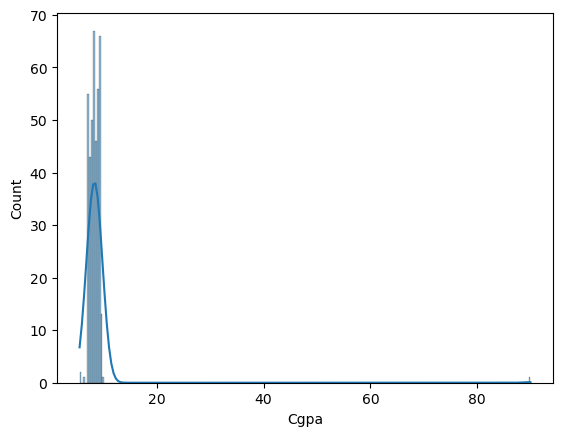

In [24]:
# CGPA distribution
sns.histplot(df['Cgpa'], kde=True)
plt.show()


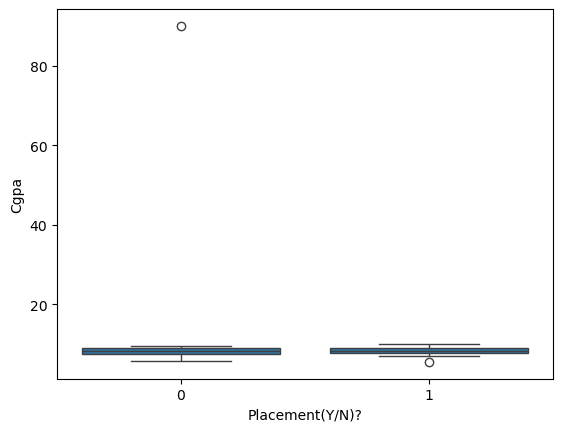

In [25]:

# Placement vs CGPA
sns.boxplot(x='Placement(Y/N)?', y='Cgpa', data=df)
plt.show()


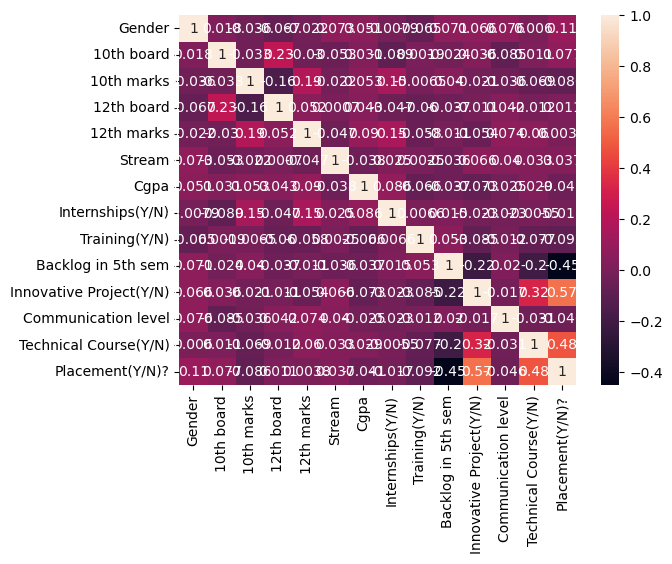

In [26]:

# Correlation heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()

Model Building

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [35]:
X = df[[
    'Cgpa',
    'Internships(Y/N)',
    'Training(Y/N)',
    'Backlog in 5th sem',
    'Innovative Project(Y/N)',
    'Communication level',
    'Technical Course(Y/N)'
]]

y = df['Placement(Y/N)?']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8888888888888888


Save Model

In [39]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))